### Network Extraction (Co-investment Pairs)

In [1]:
import pandas as pd
import numpy as np
import os
import itertools

# 1. Load the raw transactional data to get investor combinations per round
input_path = '../data/raw/Startup_Funding_Cleaned.csv'
df = pd.read_csv(input_path)

# 2. Drop rows where investor name is undisclosed or missing
df = df[df['Investor_Name'].notna()]
df = df[~df['Investor_Name'].str.lower().str.contains('undisclosed', na=False)]

# 3. Group by funding round to find investors who invested together
round_groups = df.groupby('funding_round_id')['Investor_Name'].apply(list)

# 4. Generate co-investment links (edges)
co_investment_pairs = []
for investors in round_groups:
    if len(investors) > 1:
        # Create pairs of all unique combinations of investors in this round
        for pair in itertools.combinations(sorted(list(set(investors))), 2):
            co_investment_pairs.append(pair)

# 5. Convert to an edge list DataFrame
edges_df = pd.DataFrame(co_investment_pairs, columns=['Source', 'Target'])
edges_df = edges_df.groupby(['Source', 'Target']).size().reset_index(name='Weight')

print("Investor Network links extracted successfully!")
print(f"Total Unique Co-investment relationships: {edges_df.shape[0]}")
edges_df.sort_values(by='Weight', ascending=False).head(5)

Investor Network links extracted successfully!
Total Unique Co-investment relationships: 97332


,Source,Target,Weight
93071,SV Angel,Y Combinator,58
51734,First Round Capital,SV Angel,57
11010,Andreessen Horowitz,SV Angel,57
76880,Lerer Ventures,SV Angel,53
20644,Benchmark,DAG Ventures,53


### Top Co-Investment Partnerships Visualization

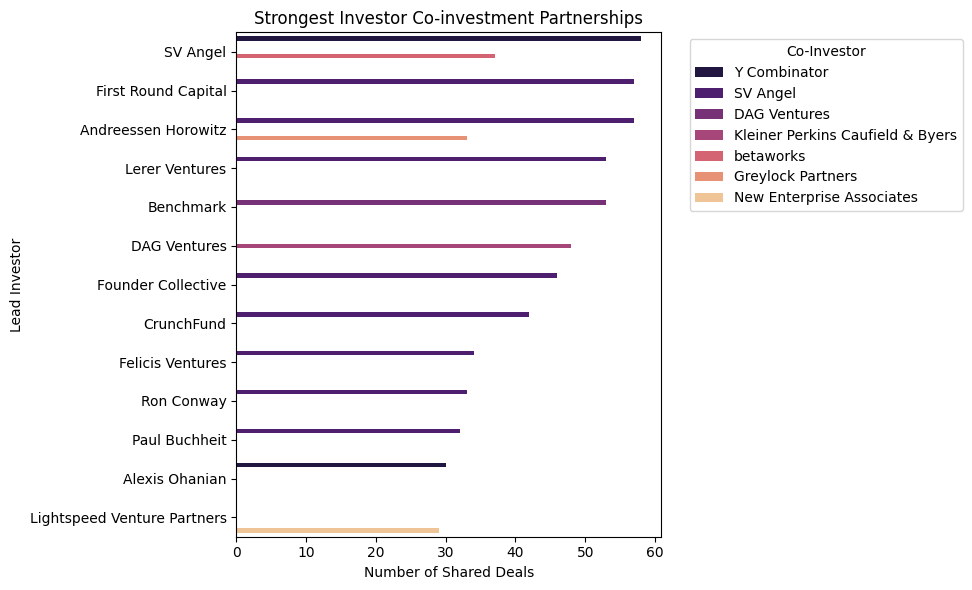

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter out the strongest relationships to keep the chart clean
strong_links = edges_df.sort_values(by='Weight', ascending=False).head(15)

# 2. Plot the strongest investor relationships
plt.figure(figsize=(10, 6))
sns.barplot(data=strong_links, x='Weight', y='Source', hue='Target', palette='magma')
plt.title("Strongest Investor Co-investment Partnerships")
plt.xlabel("Number of Shared Deals")
plt.ylabel("Lead Investor")
plt.legend(title="Co-Investor", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Export Network Data for Dashboard Injection

In [3]:
# Create processed directory if missing
os.makedirs('../data/processed', exist_ok=True)

# Export the network edges to be consumed by the dashboard later
output_path = '../data/processed/investor_network_edges.csv'
edges_df.to_csv(output_path, index=False)

print(f"Success! Investor network graph dataset saved at:\n{output_path}")

Success! Investor network graph dataset saved at:
../data/processed/investor_network_edges.csv
